# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries imported successfully")

All libraries imported successfully


In [3]:
df = pd.read_csv("clean_energy_data.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.head()


,timestamp,room,student,appliance,energy_kwh,hour,day,weekday
0,2024-01-01,Room-1,Student_A,AC,1.500,0,1,Monday
1,2024-01-01,Room-1,Student_A,Fan,0.048,0,1,Monday
2,2024-01-01,Room-1,Student_A,Light,0.010,0,1,Monday
3,2024-01-01,Room-1,Student_A,Laptop,0.056,0,1,Monday
4,2024-01-01,Room-1,Student_A,Refrigerator,0.220,0,1,Monday


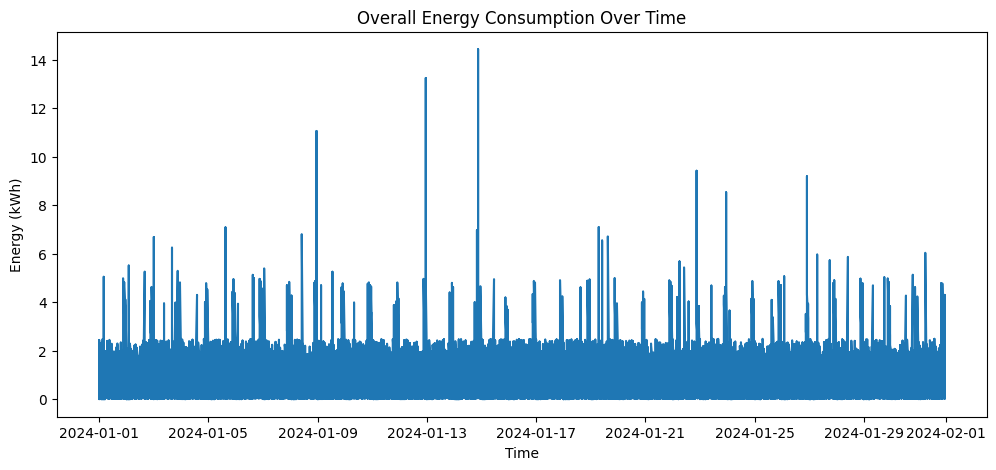

In [4]:
plt.figure(figsize=(12,5))
plt.plot(df["timestamp"], df["energy_kwh"])
plt.title("Overall Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Energy (kWh)")
plt.show()


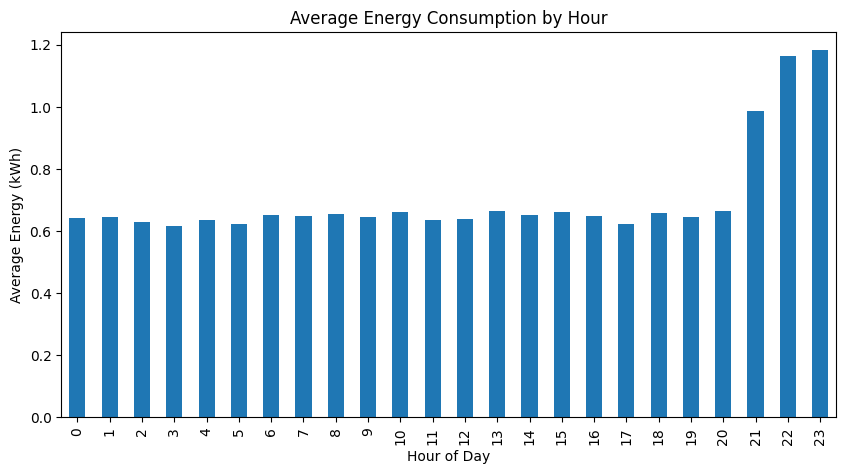

In [19]:
hourly_avg = df.groupby("hour")["energy_kwh"].mean()

plt.figure(figsize=(10,5))
hourly_avg.plot(kind="bar")
plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy (kWh)")
plt.show()


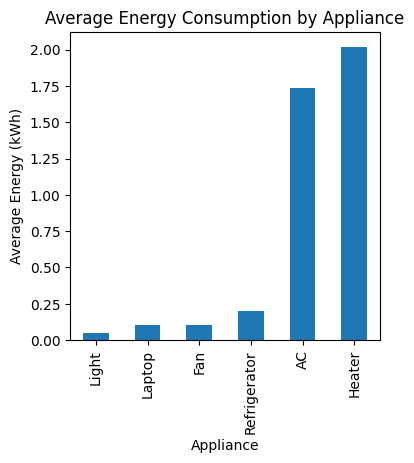

In [17]:
appliance_avg = df.groupby("appliance")["energy_kwh"].mean().sort_values(ascending=True)

plt.figure(figsize=(4,4))
appliance_avg.plot(kind="bar")
plt.title("Average Energy Consumption by Appliance")
plt.xlabel("Appliance")
plt.ylabel("Average Energy (kWh)")
plt.show()


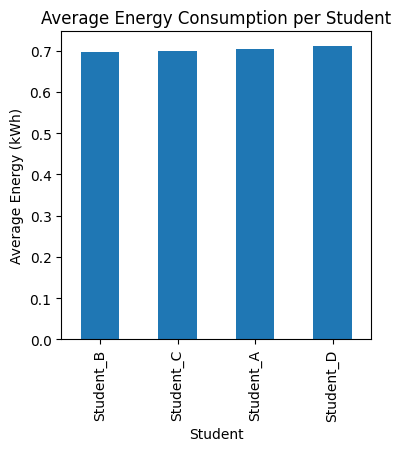

In [15]:
student_avg = df.groupby("student")["energy_kwh"].mean().sort_values(ascending=True)

plt.figure(figsize=(4,4))
student_avg.plot(kind="bar")
plt.title("Average Energy Consumption per Student")
plt.xlabel("Student")
plt.ylabel("Average Energy (kWh)")
plt.show()


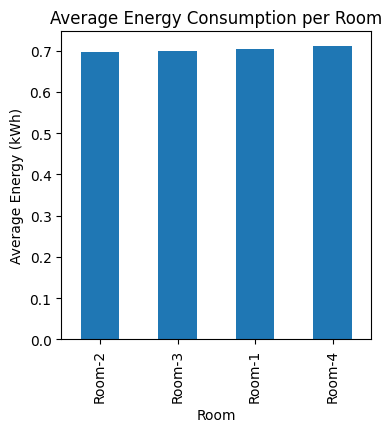

In [14]:
room_avg = df.groupby("room")["energy_kwh"].mean().sort_values(ascending=True)

plt.figure(figsize=(4,4))
room_avg.plot(kind="bar")
plt.title("Average Energy Consumption per Room")
plt.xlabel("Room")
plt.ylabel("Average Energy (kWh)")
plt.show()


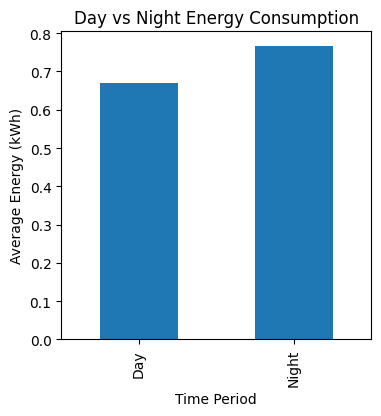

In [21]:
df["time_period"] = df["hour"].apply(lambda x: "Night" if (x >= 22 or x <= 5) else "Day")

time_usage = df.groupby("time_period")["energy_kwh"].mean().sort_values(ascending=True)

plt.figure(figsize=(4,4))
time_usage.plot(kind="bar")
plt.title("Day vs Night Energy Consumption")
plt.xlabel("Time Period")
plt.ylabel("Average Energy (kWh)")
plt.show()


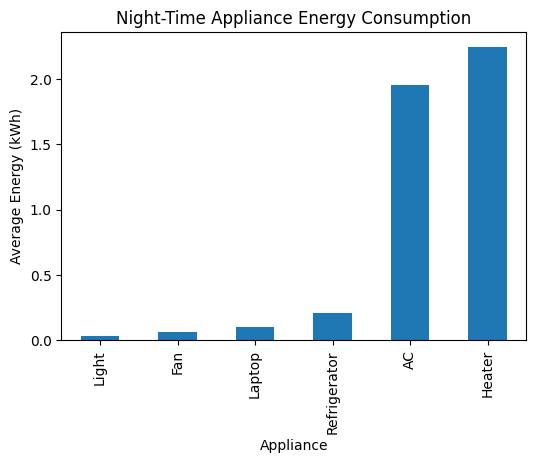

In [24]:
night_data = df[df["time_period"] == "Night"]

night_appliance = night_data.groupby("appliance")["energy_kwh"].mean().sort_values(ascending=True)

plt.figure(figsize=(6,4))
night_appliance.plot(kind="bar")
plt.title("Night-Time Appliance Energy Consumption")
plt.xlabel("Appliance")
plt.ylabel("Average Energy (kWh)")
plt.show()


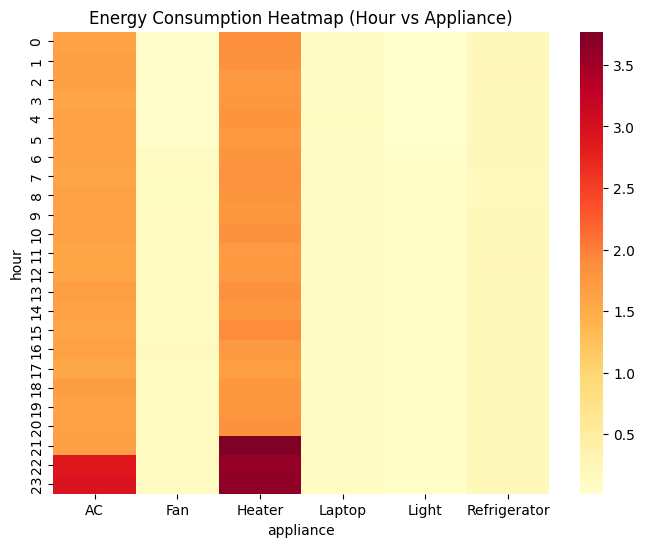

In [30]:
pivot_table = df.pivot_table(
    values="energy_kwh",
    index="hour",
    columns="appliance",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, cmap="YlOrRd")
plt.title("Energy Consumption Heatmap (Hour vs Appliance)")
plt.show()


# INSIGHTS FROM EDA:

### 1. Energy consumption peaks during evening and late-night hours.
### 2. AC and Heater are the highest power-consuming appliances.
### 3. Night-time usage contributes significantly to total wastage.
### 4. Certain students and rooms show consistently higher usage.
### 5. Peak demand hours align with leisure and sleep time usage.
